# Modelo Clásico 1 — LSTM

**Autor:** Felipe Reyes  
**Proyecto:** Aprendizaje Profundo · Maestría en IA · Pontificia Universidad Javeriana · 2026  
**Dataset:** Andalusian Hotels Reviews (5 clases, desbalanceado)

---

## Estrategia

1. **Preprocessing temporal** inline (limpieza + tokenización básica) para poder entrenar sin depender de `src/preprocessing.py` de Yibby.
2. **Arquitectura LSTM**: `Embedding(vocab_size, 128) → LSTM(128) → Dense(64, relu) → Dropout(0.3) → Dense(5)`
3. **Entrenamiento** con `src/training.py` de Daniel (early stopping, checkpoints, logging).
4. **Evaluación** con `src/metrics.py` de Daniel (métricas, JSON, curvas, matriz de confusión).

> **Nota:** Una vez Yibby entregue su pipeline, reemplazar la Sección 2 por una celda con `from src.preprocessing import build_pipeline` y re-entrenar.

In [1]:
# ── 1. Configuración global ──────────────────────────────────────────────────
#!pip install torch
import random, os, re, sys, pathlib
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# Semilla fija (contrato del equipo: 42)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Paths
ROOT = pathlib.Path("..")
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Semilla: {SEED}")
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Semilla: 42
Dispositivo: cpu
PyTorch: 2.12.0+cpu


## 2. Preprocessing temporal

> **Esta sección se reemplaza** por `build_pipeline()` de Yibby cuando esté disponible.  
> Por ahora: limpieza básica → tokenización por palabras → padding → DataLoaders.

In [2]:
# ── 2a. Cargar splits (generados por Sebastián con semilla 42) ────────────────
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"\nDistribución de clases (train):")
print(train_df["label"].value_counts().sort_index())

Train: 12,720  |  Val: 2,726  |  Test: 2,726

Distribución de clases (train):
label
0    1174
1     696
2    1592
3    2955
4    6303
Name: count, dtype: int64


In [3]:
# ── 2b. Limpieza de texto (temporal — reemplazar por Yibby) ──────────────────

def clean_text_temp(text: str) -> str:
    """Limpieza básica: lowercase, sin URLs/emails/números, sin puntuación extra."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # URLs
    text = re.sub(r"\S+@\S+", " ", text)                   # emails
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)           # solo letras españolas
    text = re.sub(r"\s+", " ", text).strip()                # espacios múltiples
    return text

# Aplicar
train_df["clean"] = train_df["review_text"].apply(clean_text_temp)
val_df["clean"]   = val_df["review_text"].apply(clean_text_temp)
test_df["clean"]  = test_df["review_text"].apply(clean_text_temp)

print("Ejemplo limpieza:")
print(f"  Original : {train_df['review_text'].iloc[0][:120]}...")
print(f"  Limpio   : {train_df['clean'].iloc[0][:120]}...")

Ejemplo limpieza:
  Original : Es un hotel bien situado y aceptable, una buena opción para conocer la bella Granada sin gastarse una fortuna. Las habit...
  Limpio   : es un hotel bien situado y aceptable una buena opción para conocer la bella granada sin gastarse una fortuna las habitac...


In [4]:
# ── 2c. Tokenización y vocabulario (temporal — reemplazar por Yibby) ─────────

VOCAB_SIZE = 20_000
MAX_LEN    = 150      # ~P95 de longitudes en tokens
PAD_IDX    = 0
UNK_IDX    = 1

# Construir vocabulario SOLO con train (nunca val/test → data leakage)
word_counts = Counter()
for text in train_df["clean"]:
    word_counts.update(text.split())

# Top-N palabras → índices (reservando 0=PAD, 1=UNK)
most_common = word_counts.most_common(VOCAB_SIZE - 2)  # -2 por PAD y UNK
word2idx = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

actual_vocab_size = len(word2idx)
print(f"Vocabulario único en train: {len(word_counts):,}")
print(f"Vocabulario usado (top-N + PAD + UNK): {actual_vocab_size:,}")
print(f"MAX_LEN: {MAX_LEN}")


def encode_text(texts, word2idx, max_len=MAX_LEN):
    """Convierte lista de textos limpios → array (n, max_len) de índices."""
    encoded = np.full((len(texts), max_len), PAD_IDX, dtype=np.int64)
    for i, text in enumerate(texts):
        tokens = text.split()[:max_len]  # truncar
        for j, token in enumerate(tokens):
            encoded[i, j] = word2idx.get(token, UNK_IDX)
    return encoded


X_train = encode_text(train_df["clean"].tolist(), word2idx)
X_val   = encode_text(val_df["clean"].tolist(),   word2idx)
X_test  = encode_text(test_df["clean"].tolist(),   word2idx)

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print(f"\nShapes: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")
print(f"Ejemplo encoded (primeros 20 tokens): {X_train[0, :20]}")

Vocabulario único en train: 27,781
Vocabulario usado (top-N + PAD + UNK): 20,000
MAX_LEN: 150

Shapes: X_train=(12720, 150), X_val=(2726, 150), X_test=(2726, 150)
Ejemplo encoded (primeros 20 tokens): [  12   10   17   28  103    3  858   14   43  355   15  491    4 2101
  108   33 8570   14 4120   16]


In [5]:
# ── 2d. DataLoaders y class weights ──────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

BATCH_SIZE = 64

class ReviewDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_ds = ReviewDataset(X_train, y_train)
val_ds   = ReviewDataset(X_val,   y_val)
test_ds  = ReviewDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# Class weights (dataset desbalanceado)
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32)

print("Class weights:")
for i, w in enumerate(weights):
    print(f"  Clase {i} ({i+1}★): {w:.3f}  (n={np.sum(y_train==i)})")

print(f"\nBatch check: {next(iter(train_loader))[0].shape}, {next(iter(train_loader))[1].shape}")

Class weights:
  Clase 0 (1★): 2.167  (n=1174)
  Clase 1 (2★): 3.655  (n=696)
  Clase 2 (3★): 1.598  (n=1592)
  Clase 3 (4★): 0.861  (n=2955)
  Clase 4 (5★): 0.404  (n=6303)

Batch check: torch.Size([64, 150]), torch.Size([64])


## 3. Arquitectura LSTM

```
Embedding(vocab_size, 128, padding_idx=0)
    → LSTM(input=128, hidden=128, dropout=0.3)
    → Linear(128 → 64) + ReLU
    → Dropout(0.3)
    → Linear(64 → 5)
```

- LSTM unidireccional, 1 capa (modelo "sencillo" — la línea base).
- Se toma el **último hidden state** como representación de la secuencia.
- Embeddings entrenables desde cero (sin pre-entrenados).

In [6]:
# ── 3. Definición del modelo LSTM ─────────────────────────────────────────────

class LSTMClassifier(nn.Module):
    """
    Modelo Clásico 1: LSTM unidireccional para clasificación de texto.
    
    Arquitectura:
        Embedding → LSTM → último hidden state → Dense(relu) → Dropout → Dense(logits)
    """
    def __init__(self, vocab_size, embedding_dim=128, hidden_size=128,
                 num_classes=5, dropout=0.3, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            dropout=0,         # dropout entre capas LSTM (no aplica con 1 capa)
        )
        self.fc1     = nn.Linear(hidden_size, 64)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2     = nn.Linear(64, num_classes)
    
    def forward(self, x):
        # x: (batch, seq_len) de índices enteros
        emb = self.embedding(x)                    # (batch, seq_len, emb_dim)
        lstm_out, (h_n, c_n) = self.lstm(emb)      # h_n: (1, batch, hidden)
        hidden = h_n.squeeze(0)                     # (batch, hidden)
        out = self.fc1(hidden)                      # (batch, 64)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)                         # (batch, num_classes)
        return out

# Instanciar
model = LSTMClassifier(
    vocab_size=actual_vocab_size,
    embedding_dim=128,
    hidden_size=128,
    num_classes=5,
    dropout=0.3,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Arquitectura:\n{model}")
print(f"\nParámetros entrenables: {n_params:,}")

Arquitectura:
LSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)

Parámetros entrenables: 2,700,677


## 4. Entrenamiento

Usando `src/training.py` de Daniel:
- **Optimizer:** Adam, lr=1e-3
- **Early stopping:** paciencia 5
- **Class weights:** activados (dataset desbalanceado)
- **Gradient clipping:** 1.0
- **LR scheduler:** ReduceLROnPlateau

In [7]:
# ── 4. Entrenamiento con src/training.py ──────────────────────────────────────
from src.training import train as train_model

config = {
    # Metadatos (para el JSON estandarizado)
    "model_name":       "lstm",
    "owner":            "Felipe",
    "track":            "PP",
    # Arquitectura
    "embedding_dim":    128,
    "hidden_size":      128,
    "dropout":          0.3,
    # Entrenamiento
    "n_epochs":         30,
    "lr":               1e-3,
    "patience":         5,
    "clip_grad":        1.0,
    "weight_decay":     0.0,
    "use_lr_scheduler": True,
    "use_class_weights":True,
    "class_weights":    class_weights,
    "checkpoint_path":  str(RESULTS_DIR / "lstm_best.pt"),
    "seed":             SEED,
}

# Entrenar
metrics_dict = train_model(model, train_loader, val_loader, config)

Dispositivo: cpu
Parámetros entrenables: 2,700,677

  Entrenando: lstm  |  Owner: Felipe
Época   1/30 | loss: 1.5924  acc: 0.3156 | val_loss: 1.5606  val_acc: 0.4721
    ✓ Checkpoint guardado (val_loss=1.5606) → ..\results\lstm_best.pt
Época   2/30 | loss: 1.5467  acc: 0.3910 | val_loss: 1.5166  val_acc: 0.3386
    ✓ Checkpoint guardado (val_loss=1.5166) → ..\results\lstm_best.pt
Época   3/30 | loss: 1.4631  acc: 0.4489 | val_loss: 1.4453  val_acc: 0.5209
    ✓ Checkpoint guardado (val_loss=1.4453) → ..\results\lstm_best.pt
Época   4/30 | loss: 1.4449  acc: 0.4487 | val_loss: 1.4198  val_acc: 0.4560
    ✓ Checkpoint guardado (val_loss=1.4198) → ..\results\lstm_best.pt
Época   5/30 | loss: 1.3728  acc: 0.4876 | val_loss: 1.4574  val_acc: 0.5455
    Early stopping: 1/5 sin mejora.
Época   6/30 | loss: 1.3503  acc: 0.4790 | val_loss: 1.3804  val_acc: 0.5444
    ✓ Checkpoint guardado (val_loss=1.3804) → ..\results\lstm_best.pt
Época   7/30 | loss: 1.3094  acc: 0.5165 | val_loss: 1.4284  va

## 5. Evaluación en test set y entregables

Una sola evaluación sobre test (nunca se usó para tunear).  
Genera automáticamente:
- `results/lstm_metrics.json`
- `figures/lstm_curves.png`
- `figures/lstm_confusion_matrix.png`

In [8]:
# ── 5a. Evaluación sobre test set ─────────────────────────────────────────────
from src.training import evaluate
from src.metrics import finalize_and_save

# Re-instanciar modelo con la misma arquitectura para cargar el checkpoint
model_eval = LSTMClassifier(
    vocab_size=actual_vocab_size,
    embedding_dim=128,
    hidden_size=128,
    num_classes=5,
    dropout=0.3,
)

# Evaluar con el mejor checkpoint
y_true, y_pred = evaluate(
    model_eval,
    test_loader,
    checkpoint_path=config["checkpoint_path"],
    config=config,
)

print(f"Predicciones generadas: {len(y_pred)} muestras")

Predicciones generadas: 2726 muestras



── Métricas de evaluación (test set) ──────────────────────
  Accuracy        : 0.2982
  Precision macro : 0.4340
  Recall macro    : 0.4012
  F1 macro        : 0.3127
  F1 por clase:
    Clase 1★: 0.6353
    Clase 2★: 0.2531
    Clase 3★: 0.2470
    Clase 4★: 0.4108
    Clase 5★: 0.0175
────────────────────────────────────────────────────────────

  JSON guardado → ..\results\lstm_metrics.json
  Curvas guardadas → ..\figures\lstm_curves.png


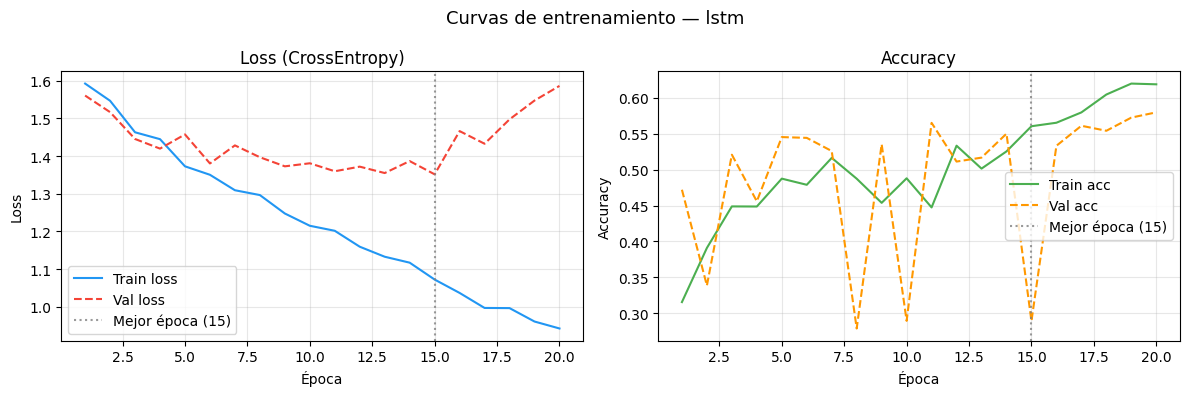

  Matriz de confusión guardada → ..\figures\lstm_confusion_matrix.png


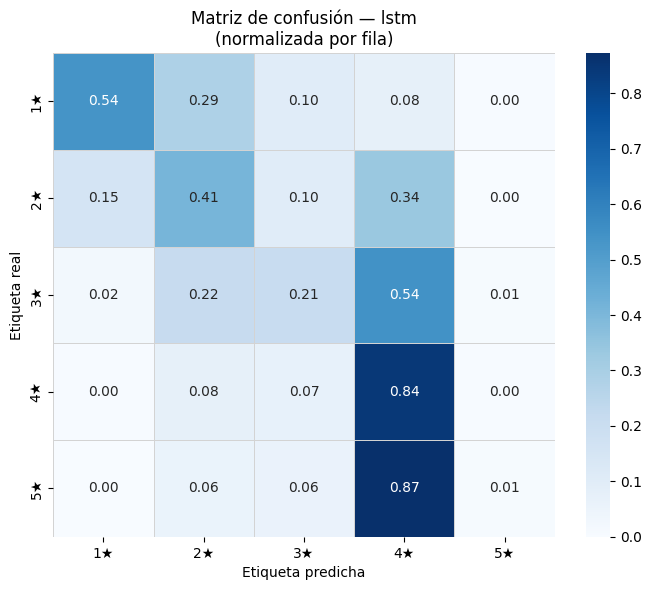


=== Resumen final ===
F1 macro:  0.3127
Accuracy:  0.2982
Épocas:    20
Mejor época: 15
Tiempo:    284.4s


In [9]:
# ── 5b. Generar métricas, JSON, curvas y matriz de confusión ─────────────────

CLASS_NAMES = ["1★", "2★", "3★", "4★", "5★"]

metrics_dict = finalize_and_save(
    y_true       = y_true,
    y_pred       = y_pred,
    metrics_dict = metrics_dict,
    results_dir  = str(RESULTS_DIR),
    figures_dir  = str(FIGURES_DIR),
    class_names  = CLASS_NAMES,
    show_plots   = True,       # Mostrar en notebook
)

print("\n=== Resumen final ===")
print(f"F1 macro:  {metrics_dict['metrics']['f1_macro']:.4f}")
print(f"Accuracy:  {metrics_dict['metrics']['accuracy']:.4f}")
print(f"Épocas:    {metrics_dict['training']['epochs_run']}")
print(f"Mejor época: {metrics_dict['training']['best_epoch']}")
print(f"Tiempo:    {metrics_dict['training']['training_time_seconds']}s")

## 6. Integración con pipeline de Yibby (post-reunión)

Cuando Yibby entregue `src/preprocessing.py` funcional:

1. **Reemplazar toda la Sección 2** (celdas 2a–2d) por:

```python
from src.preprocessing import build_pipeline

pipeline = build_pipeline({
    "data_dir":    str(DATA_DIR),
    "text_col":    "review_text",
    "label_col":   "label",
    "vocab_size":  20_000,     # ajustar según Yibby
    "max_len":     150,        # ajustar según Yibby
    "batch_size":  64,
})

train_loader  = pipeline["train_loader"]
val_loader    = pipeline["val_loader"]
test_loader   = pipeline["test_loader"]
class_weights = pipeline["class_weights"]
actual_vocab_size = pipeline["vocab_size"]
```

2. **Actualizar `actual_vocab_size`** en la celda del modelo si cambió.
3. **Re-ejecutar desde la Sección 3** en adelante.

## 7. Segundo intento — Ajuste de hiperparámetros

Problemas detectados en el primer intento:
- **Class weights sobrecompensan**: F1 de clase 5★ = 0.02 (la ignora casi por completo)
- **Val accuracy oscila mucho**: lr=1e-3 puede ser agresivo para LSTM
- **Val loss sube desde época 15**: overfitting claro

Cambios para este intento:
1. **Sin class weights** — dejar que el modelo aprenda la distribución natural
2. **lr = 3e-4** — más conservador, menos oscilación
3. Misma arquitectura para comparación justa

In [10]:
# ── 7a. Entrenar LSTM v2 (sin class weights, lr=3e-4) ────────────────────────
from importlib import reload
import src.training as training_module
reload(training_module)
from src.training import train as train_model_v2, evaluate as evaluate_v2

# Modelo nuevo (pesos frescos)
model_v2 = LSTMClassifier(
    vocab_size=actual_vocab_size,
    embedding_dim=128,
    hidden_size=128,
    num_classes=5,
    dropout=0.3,
)

config_v2 = {
    "model_name":       "lstm_v2",
    "owner":            "Felipe",
    "track":            "PP",
    "embedding_dim":    128,
    "hidden_size":      128,
    "dropout":          0.3,
    "n_epochs":         30,
    "lr":               3e-4,          # más bajo
    "patience":         5,
    "clip_grad":        1.0,
    "weight_decay":     0.0,
    "use_lr_scheduler": True,
    "use_class_weights":False,         # sin class weights
    # "class_weights":  NO se pasa
    "checkpoint_path":  str(RESULTS_DIR / "lstm_v2_best.pt"),
    "seed":             SEED,
}

metrics_dict_v2 = train_model_v2(model_v2, train_loader, val_loader, config_v2)

Dispositivo: cpu
Parámetros entrenables: 2,700,677

  Entrenando: lstm_v2  |  Owner: Felipe
Época   1/30 | loss: 1.3713  acc: 0.4560 | val_loss: 1.2885  val_acc: 0.4982
    ✓ Checkpoint guardado (val_loss=1.2885) → ..\results\lstm_v2_best.pt
Época   2/30 | loss: 1.3047  acc: 0.4886 | val_loss: 1.2683  val_acc: 0.4406
    ✓ Checkpoint guardado (val_loss=1.2683) → ..\results\lstm_v2_best.pt
Época   3/30 | loss: 1.2761  acc: 0.4870 | val_loss: 1.2227  val_acc: 0.4956
    ✓ Checkpoint guardado (val_loss=1.2227) → ..\results\lstm_v2_best.pt
Época   4/30 | loss: 1.2235  acc: 0.4998 | val_loss: 1.1905  val_acc: 0.4971
    ✓ Checkpoint guardado (val_loss=1.1905) → ..\results\lstm_v2_best.pt
Época   5/30 | loss: 1.2085  acc: 0.4972 | val_loss: 1.1938  val_acc: 0.5037
    Early stopping: 1/5 sin mejora.
Época   6/30 | loss: 1.1919  acc: 0.5054 | val_loss: 1.1854  val_acc: 0.5147
    ✓ Checkpoint guardado (val_loss=1.1854) → ..\results\lstm_v2_best.pt
Época   7/30 | loss: 1.1825  acc: 0.5069 | va


── Métricas de evaluación (test set) ──────────────────────
  Accuracy        : 0.5675
  Precision macro : 0.4465
  Recall macro    : 0.4073
  F1 macro        : 0.3830
  F1 por clase:
    Clase 1★: 0.5993
    Clase 2★: 0.0503
    Clase 3★: 0.3488
    Clase 4★: 0.1692
    Clase 5★: 0.7472
────────────────────────────────────────────────────────────

  JSON guardado → ..\results\lstm_v2_metrics.json
  Curvas guardadas → ..\figures\lstm_v2_curves.png


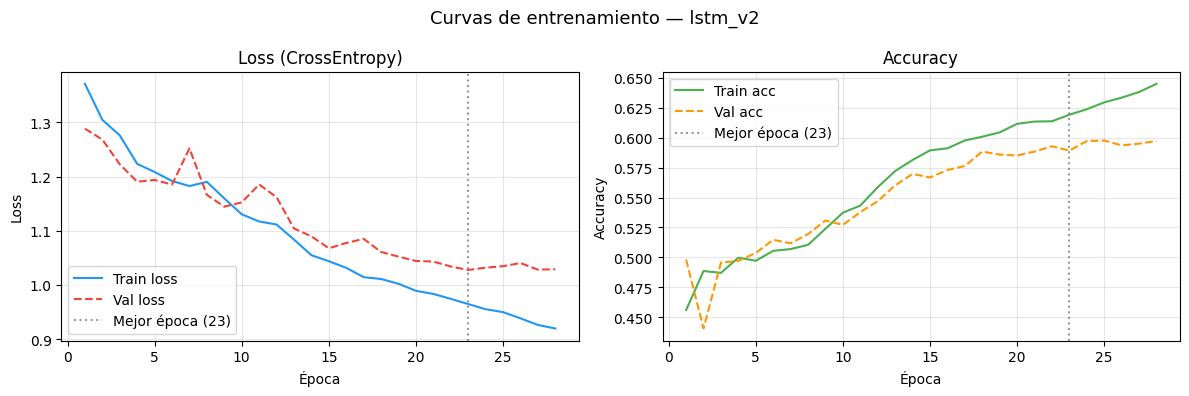

  Matriz de confusión guardada → ..\figures\lstm_v2_confusion_matrix.png


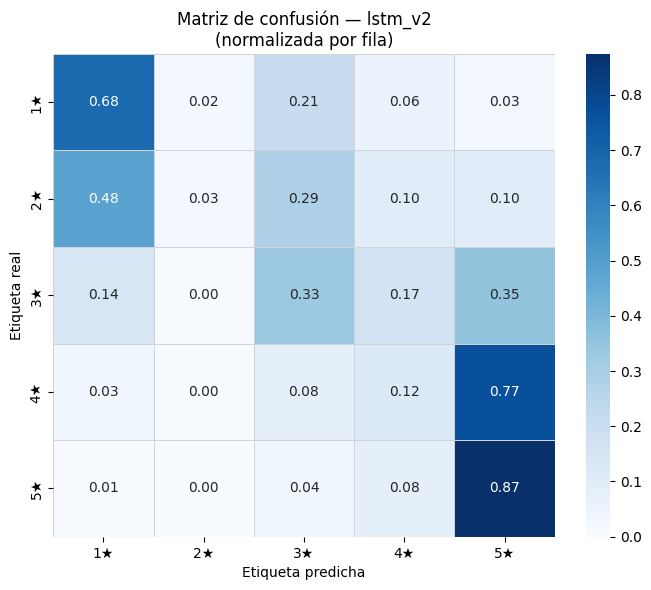


=== Resumen LSTM v2 ===
F1 macro:    0.3830
Accuracy:    0.5675
Mejor época: 23
Tiempo:      378.9s


In [11]:
# ── 7b. Evaluar LSTM v2 ──────────────────────────────────────────────────────
from src.metrics import finalize_and_save as finalize_v2

model_eval_v2 = LSTMClassifier(
    vocab_size=actual_vocab_size,
    embedding_dim=128,
    hidden_size=128,
    num_classes=5,
    dropout=0.3,
)

y_true_v2, y_pred_v2 = evaluate_v2(
    model_eval_v2,
    test_loader,
    checkpoint_path=config_v2["checkpoint_path"],
    config=config_v2,
)

metrics_dict_v2 = finalize_v2(
    y_true       = y_true_v2,
    y_pred       = y_pred_v2,
    metrics_dict = metrics_dict_v2,
    results_dir  = str(RESULTS_DIR),
    figures_dir  = str(FIGURES_DIR),
    class_names  = CLASS_NAMES,
    show_plots   = True,
)

print("\n=== Resumen LSTM v2 ===")
print(f"F1 macro:    {metrics_dict_v2['metrics']['f1_macro']:.4f}")
print(f"Accuracy:    {metrics_dict_v2['metrics']['accuracy']:.4f}")
print(f"Mejor época: {metrics_dict_v2['training']['best_epoch']}")
print(f"Tiempo:      {metrics_dict_v2['training']['training_time_seconds']}s")

In [12]:
# ── 7c. Comparación v1 vs v2 ─────────────────────────────────────────────────
comparison = pd.DataFrame([
    {
        "Versión": "LSTM v1 (class weights, lr=1e-3)",
        "F1 macro": metrics_dict["metrics"]["f1_macro"],
        "Accuracy": metrics_dict["metrics"]["accuracy"],
        "F1 1★": metrics_dict["metrics"]["f1_per_class"]["1★"],
        "F1 2★": metrics_dict["metrics"]["f1_per_class"]["2★"],
        "F1 3★": metrics_dict["metrics"]["f1_per_class"]["3★"],
        "F1 4★": metrics_dict["metrics"]["f1_per_class"]["4★"],
        "F1 5★": metrics_dict["metrics"]["f1_per_class"]["5★"],
        "Mejor época": metrics_dict["training"]["best_epoch"],
        "Tiempo (s)": metrics_dict["training"]["training_time_seconds"],
    },
    {
        "Versión": "LSTM v2 (sin weights, lr=3e-4)",
        "F1 macro": metrics_dict_v2["metrics"]["f1_macro"],
        "Accuracy": metrics_dict_v2["metrics"]["accuracy"],
        "F1 1★": metrics_dict_v2["metrics"]["f1_per_class"]["1★"],
        "F1 2★": metrics_dict_v2["metrics"]["f1_per_class"]["2★"],
        "F1 3★": metrics_dict_v2["metrics"]["f1_per_class"]["3★"],
        "F1 4★": metrics_dict_v2["metrics"]["f1_per_class"]["4★"],
        "F1 5★": metrics_dict_v2["metrics"]["f1_per_class"]["5★"],
        "Mejor época": metrics_dict_v2["training"]["best_epoch"],
        "Tiempo (s)": metrics_dict_v2["training"]["training_time_seconds"],
    },
])

print("=== Comparación de configuraciónes ===\n")
print(comparison.to_string(index=False))

=== Comparación de configuraciónes ===

                         Versión  F1 macro  Accuracy    F1 1★    F1 2★    F1 3★    F1 4★    F1 5★  Mejor época  Tiempo (s)
LSTM v1 (class weights, lr=1e-3)  0.312730  0.298239 0.635294 0.253112 0.246957 0.410769 0.017518           15       284.4
  LSTM v2 (sin weights, lr=3e-4)  0.382969  0.567498 0.599303 0.050314 0.348765 0.169231 0.747232           23       378.9


## 8. Integración con pipeline definitivo de Yibby

Reemplaza el preprocessing temporal (Sección 2) por `build_pipeline()` de Yibby.
Re-entrena el LSTM con el pipeline definitivo para generar los resultados finales.

**Cambios respecto a secciónes anteriores:**
- Pipeline de Yibby: `src/preprocessing.py` con `clean_text()`, `build_tokenizer()`, etc.
- MAX_LEN = 150 (basado en P95 del EDA)
- Labels ya son 0-indexed (no necesita `- 1`)
- Se prueban dos variantes: con y sin class weights

In [ ]:
# ── 8a. Cargar pipeline definitivo de Yibby ──────────────────────────────────
from importlib import reload
import src.preprocessing as prep_module
reload(prep_module)
from src.preprocessing import build_pipeline

pipeline = build_pipeline({
    "data_dir":    str(DATA_DIR),
    "text_col":    "review_text",
    "label_col":   "label",
    "vocab_size":  20_000,
    "max_len":     150,       # P95 del EDA = 148, redondeado a 150
    "batch_size":  64,
})

# Extraer componentes
train_loader_y  = pipeline["train_loader"]
val_loader_y    = pipeline["val_loader"]
test_loader_y   = pipeline["test_loader"]
class_weights_y = pipeline["class_weights"]
vocab_size_y    = pipeline["vocab_size"]

print(f"\nVocabulario real: {vocab_size_y:,}")
print(f"Class weights: {class_weights_y}")

# Verificar un batch
X_b, y_b = next(iter(train_loader_y))
print(f"\nBatch check: X={X_b.shape}, y={y_b.shape}")
print(f"Labels únicos en batch: {y_b.unique().tolist()}")
assert y_b.min() >= 0 and y_b.max() <= 4, f"Labels fuera de rango: min={y_b.min()}, max={y_b.max()}"
print("Labels OK (0-4)")

In [ ]:
# ── 8b. Entrenar LSTM v3 con pipeline Yibby (sin class weights, lr=3e-4) ─────
# Basado en la mejor configuración de v2 + preprocessing definitivo

reload(training_module)
from src.training import train as train_model_v3, evaluate as evaluate_v3

model_v3 = LSTMClassifier(
    vocab_size=vocab_size_y,   # vocabulario real del pipeline de Yibby
    embedding_dim=128,
    hidden_size=128,
    num_classes=5,
    dropout=0.3,
)

config_v3 = {
    "model_name":       "lstm_v3_yibby",
    "owner":            "Felipe",
    "track":            "PP",
    "embedding_dim":    128,
    "hidden_size":      128,
    "dropout":          0.3,
    "n_epochs":         30,
    "lr":               3e-4,
    "patience":         5,
    "clip_grad":        1.0,
    "weight_decay":     0.0,
    "use_lr_scheduler": True,
    "use_class_weights": False,
    "checkpoint_path":  str(RESULTS_DIR / "lstm_v3_best.pt"),
    "seed":             SEED,
}

metrics_v3 = train_model_v3(model_v3, train_loader_y, val_loader_y, config_v3)

In [ ]:
# ── 8c. Evaluar LSTM v3 ──────────────────────────────────────────────────────
from src.metrics import finalize_and_save as finalize_v3

model_eval_v3 = LSTMClassifier(
    vocab_size=vocab_size_y,
    embedding_dim=128,
    hidden_size=128,
    num_classes=5,
    dropout=0.3,
)

y_true_v3, y_pred_v3 = evaluate_v3(
    model_eval_v3,
    test_loader_y,
    checkpoint_path=config_v3["checkpoint_path"],
    config=config_v3,
)

metrics_v3 = finalize_v3(
    y_true       = y_true_v3,
    y_pred       = y_pred_v3,
    metrics_dict = metrics_v3,
    results_dir  = str(RESULTS_DIR),
    figures_dir  = str(FIGURES_DIR),
    class_names  = CLASS_NAMES,
    show_plots   = True,
)

print("\n=== Resumen LSTM v3 (pipeline Yibby) ===")
print(f"F1 macro:    {metrics_v3['metrics']['f1_macro']:.4f}")
print(f"Accuracy:    {metrics_v3['metrics']['accuracy']:.4f}")
print(f"Mejor época: {metrics_v3['training']['best_epoch']}")
print(f"Tiempo:      {metrics_v3['training']['training_time_seconds']}s")

In [ ]:
# ── 8d. Comparación v1 vs v2 vs v3 ───────────────────────────────────────────
comparison_all = pd.DataFrame([
    {
        "Version": "v1 (temp, class weights, lr=1e-3)",
        "Pipeline": "temporal",
        "F1 macro": metrics_dict["metrics"]["f1_macro"],
        "Accuracy": metrics_dict["metrics"]["accuracy"],
        "F1 1★": metrics_dict["metrics"]["f1_per_class"]["1★"],
        "F1 2★": metrics_dict["metrics"]["f1_per_class"]["2★"],
        "F1 3★": metrics_dict["metrics"]["f1_per_class"]["3★"],
        "F1 4★": metrics_dict["metrics"]["f1_per_class"]["4★"],
        "F1 5★": metrics_dict["metrics"]["f1_per_class"]["5★"],
        "Epoca": metrics_dict["training"]["best_epoch"],
    },
    {
        "Version": "v2 (temp, sin weights, lr=3e-4)",
        "Pipeline": "temporal",
        "F1 macro": metrics_dict_v2["metrics"]["f1_macro"],
        "Accuracy": metrics_dict_v2["metrics"]["accuracy"],
        "F1 1★": metrics_dict_v2["metrics"]["f1_per_class"]["1★"],
        "F1 2★": metrics_dict_v2["metrics"]["f1_per_class"]["2★"],
        "F1 3★": metrics_dict_v2["metrics"]["f1_per_class"]["3★"],
        "F1 4★": metrics_dict_v2["metrics"]["f1_per_class"]["4★"],
        "F1 5★": metrics_dict_v2["metrics"]["f1_per_class"]["5★"],
        "Epoca": metrics_dict_v2["training"]["best_epoch"],
    },
    {
        "Version": "v3 (Yibby, sin weights, lr=3e-4)",
        "Pipeline": "Yibby",
        "F1 macro": metrics_v3["metrics"]["f1_macro"],
        "Accuracy": metrics_v3["metrics"]["accuracy"],
        "F1 1★": metrics_v3["metrics"]["f1_per_class"]["1★"],
        "F1 2★": metrics_v3["metrics"]["f1_per_class"]["2★"],
        "F1 3★": metrics_v3["metrics"]["f1_per_class"]["3★"],
        "F1 4★": metrics_v3["metrics"]["f1_per_class"]["4★"],
        "F1 5★": metrics_v3["metrics"]["f1_per_class"]["5★"],
        "Epoca": metrics_v3["training"]["best_epoch"],
    },
])

print("=" * 80)
print("COMPARACIÓN DE TODAS LAS VERSIONES DEL LSTM")
print("=" * 80)
print(comparison_all.to_string(index=False))
print()
print("→ La versión v3 usa el pipeline definitivo de Yibby.")
print("  Si los resultados mejoran, confirma que clean_text() de Yibby")
print("  es superior al preprocessing temporal.")